In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy 

data_paths = []
data_paths.append(Path(r"C:\Users\elyse\Downloads\04\15-50-33_data.csv"))
data_paths.append(Path(r"C:\Users\elyse\Downloads\04\18-17-09_data.csv"))


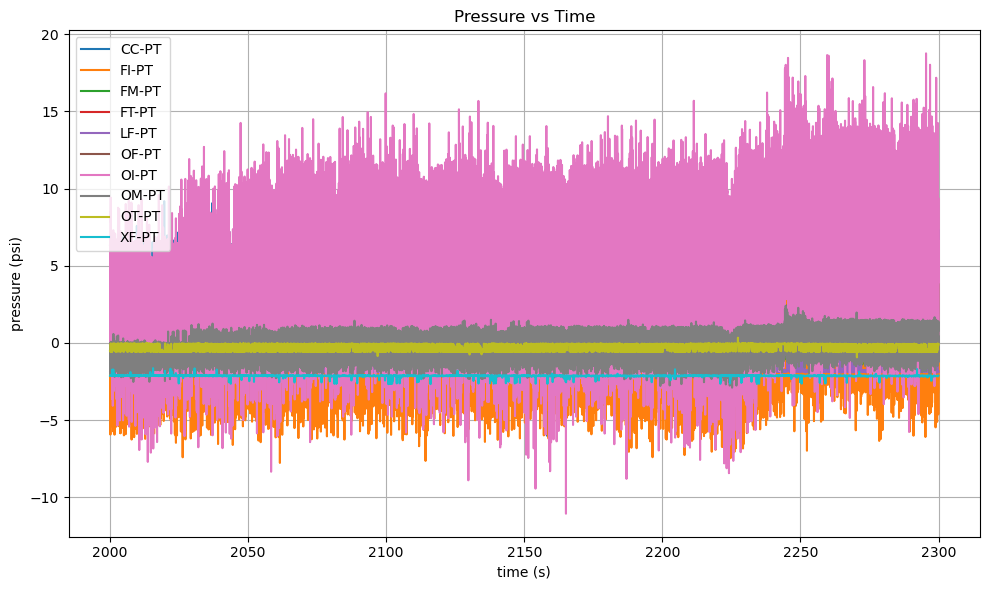

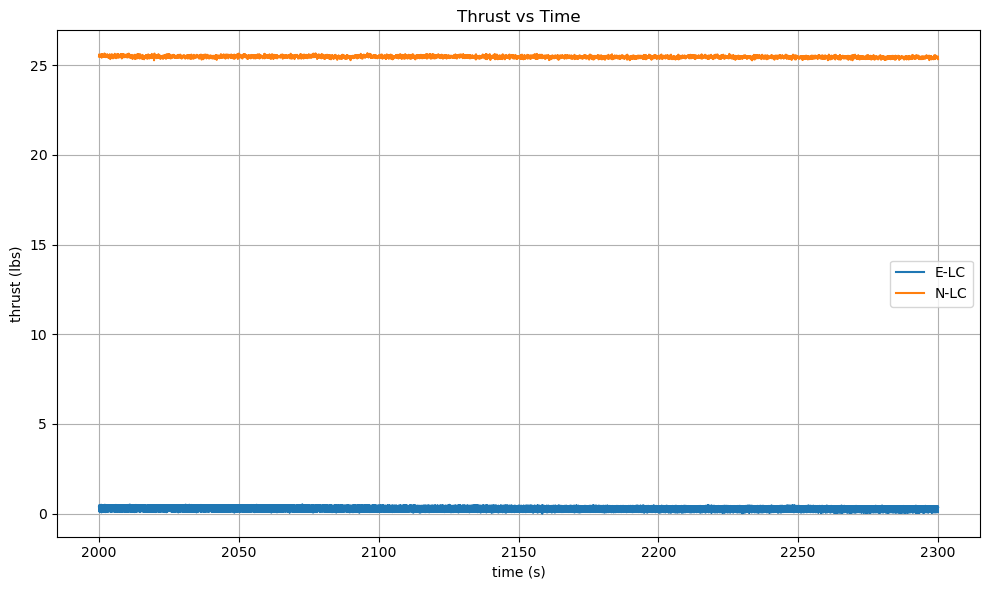

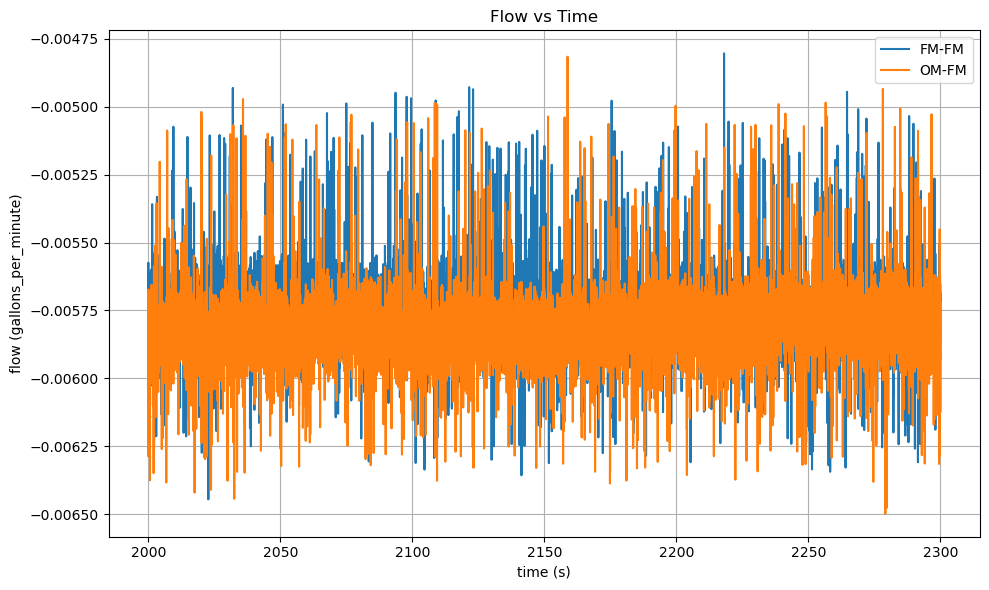

In [3]:
from IPython.display import display

df = pd.read_csv(data_paths[1], header=0)
data_matrix = df.to_numpy()

df["t_rel"] = df.t_wall - df.t_wall.min()

t, value, raw_value, voltage, units, type = {}, {}, {}, {}, {}, {}
dt = []
plots_by_type = {}

for name, g in df.groupby("sensor_name"):
    name = name.strip()
    g = g.sort_values("t_rel")
    t[name] = g.t_rel.to_numpy()
    value[name] = g.value.to_numpy()
    units[name] = g.units.iloc[0]
    type[name] = g.sensor_kind.iloc[0]
    
    mask = (t[name] > 2000) & (t[name] < 2300)
    t[name] = t[name][mask]
    value[name] = value[name][mask]

    if len(t[name]) == 0:
        continue

    sensor_type = type[name]
    if sensor_type not in plots_by_type:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.set_xlabel("time (s)")
        ax.set_ylabel(f"{sensor_type} ({units[name]})")
        ax.set_title(f"{sensor_type.title()} vs Time")
        ax.grid(True)
        plots_by_type[sensor_type] = {
            "figure": fig,
            "ax": ax,
        }

    plots_by_type[sensor_type]["ax"].plot(t[name], value[name], label=name)

for sensor_type, plot_info in plots_by_type.items():
    handles, labels = plot_info["ax"].get_legend_handles_labels()
    if not labels:
        plt.close(plot_info["figure"])
        continue
    plot_info["ax"].legend(handles, labels)
    plot_info["figure"].tight_layout()
    display(plot_info["figure"])
    plt.close(plot_info["figure"])

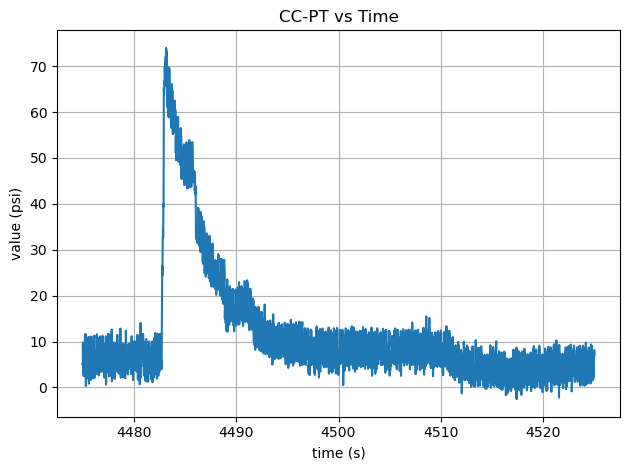

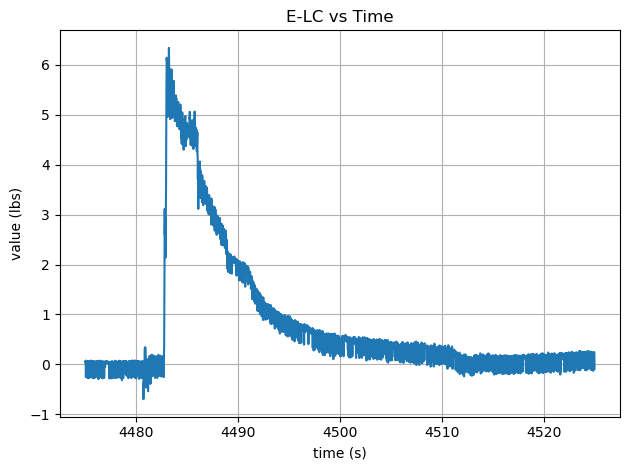

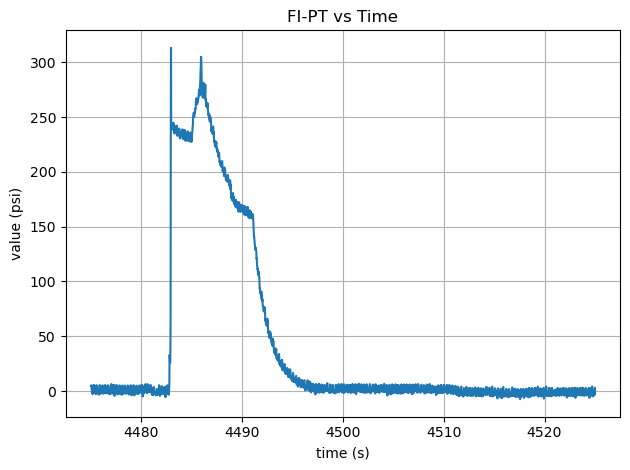

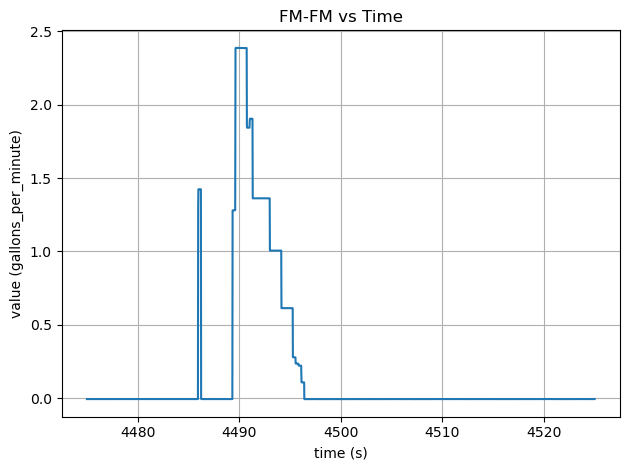

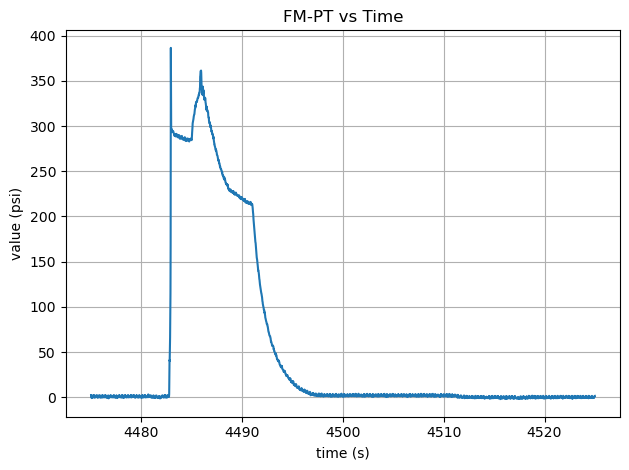

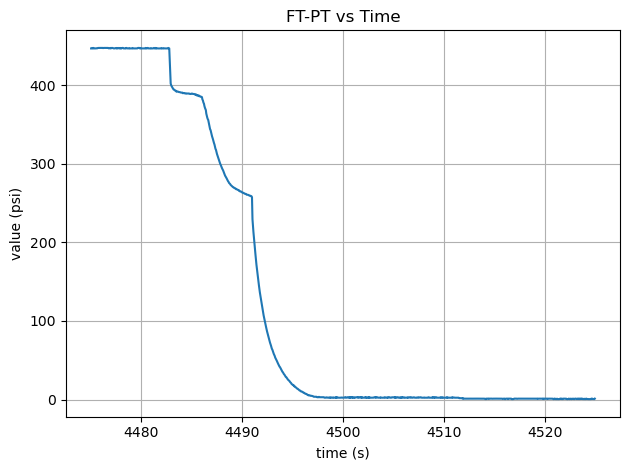

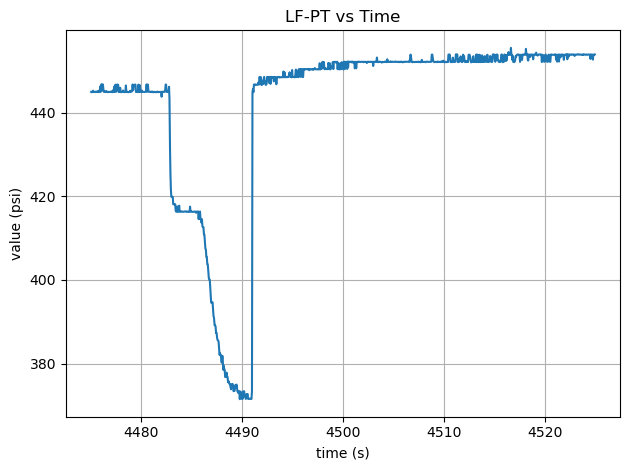

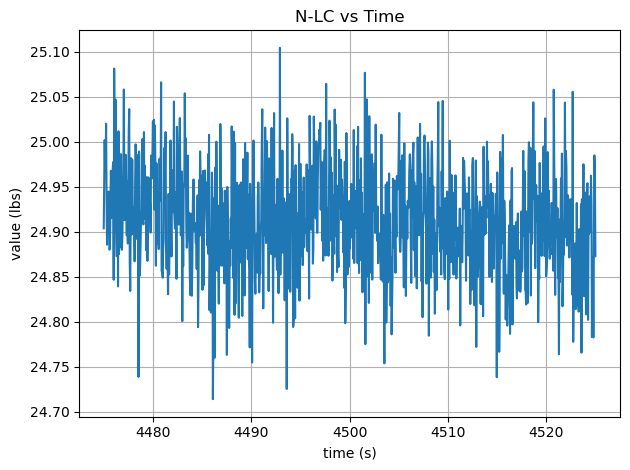

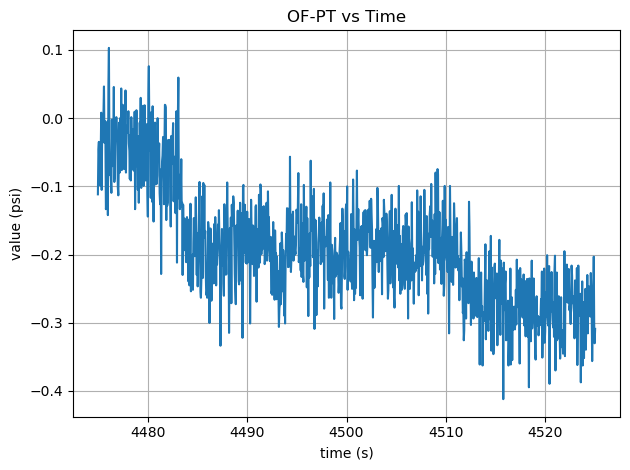

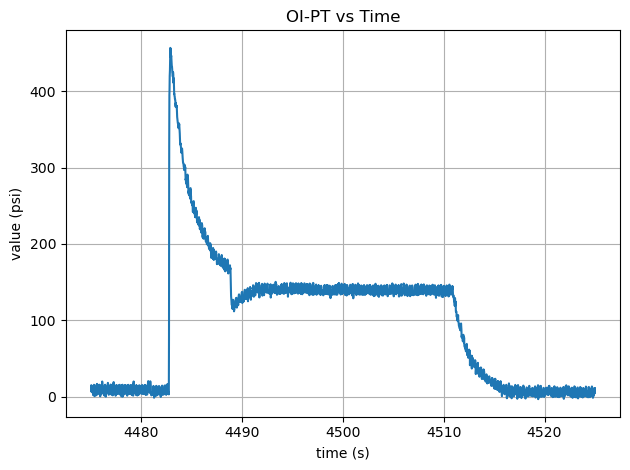

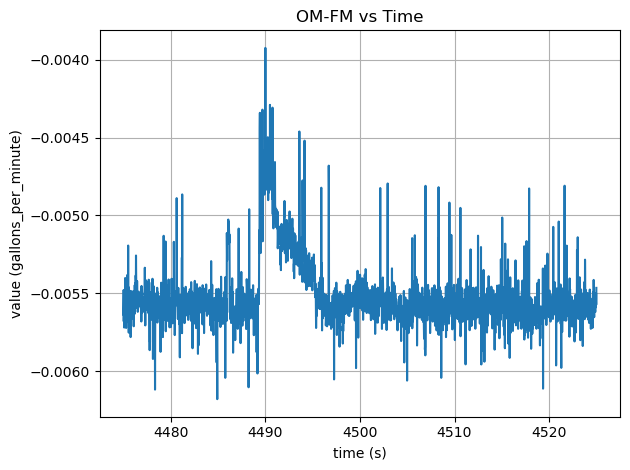

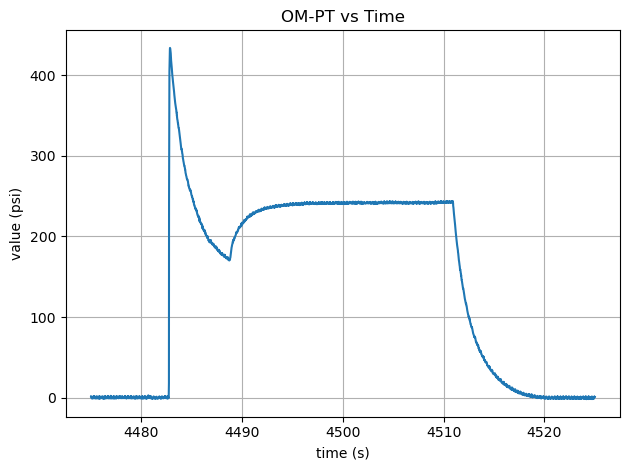

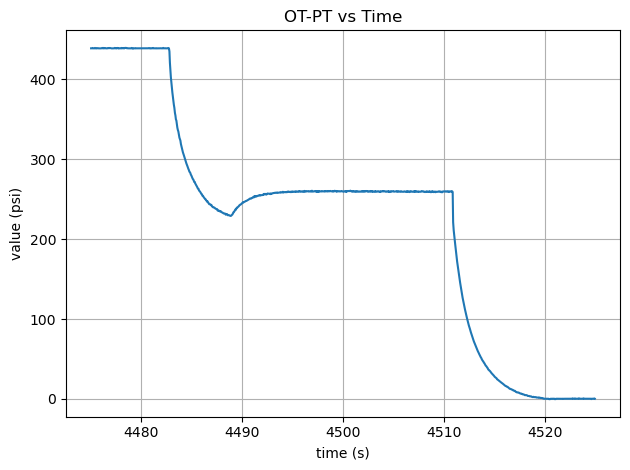

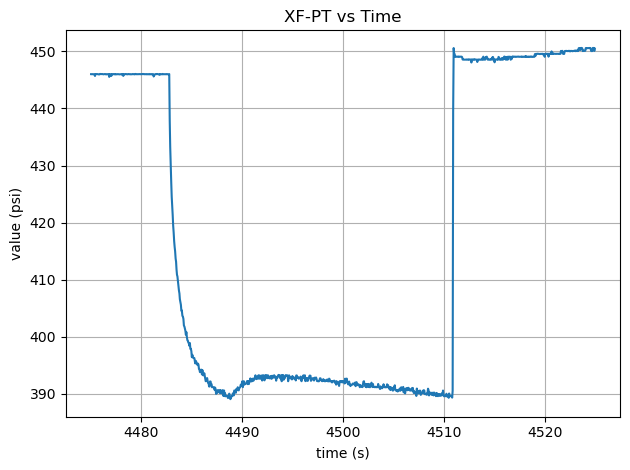

Saved truncated data to C:\Users\elyse\Downloads\04\18-17-09_data_truncated_wide.csv
Saved sampling rates to C:\Users\elyse\Downloads\04\18-17-09_data_sampling_rates.csv


,sensor_name,sensor_kind,units,sample_count,mean_dt_s,sampling_rate_hz
0,CC-PT,pressure,psi,3546,0.014098,70.930724
1,E-LC,thrust,lbs,3486,0.014344,69.714298
2,FI-PT,pressure,psi,2719,0.018392,54.371133
3,FM-FM,flow,gallons_per_minute,2719,0.018392,54.371559
4,FM-PT,pressure,psi,2718,0.018394,54.366463
5,FT-PT,pressure,psi,1040,0.048069,20.803578
6,LF-PT,pressure,psi,1039,0.048115,20.783381
7,N-LC,thrust,lbs,1009,0.049553,20.180551
8,OF-PT,pressure,psi,1035,0.048346,20.684239
9,OI-PT,pressure,psi,2717,0.018400,54.346464


,time_s,CC-PT,E-LC,FI-PT,FM-FM,FM-PT,FT-PT,LF-PT,N-LC,OF-PT,OI-PT,OM-FM,OM-PT,OT-PT,XF-PT
0,4475.002329,NaN,NaN,4.614825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4475.003849,NaN,0.05181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4475.003994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.111708,NaN,NaN,NaN,NaN,NaN
3,4475.005745,NaN,NaN,NaN,-0.005576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4475.007297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.712289,NaN,NaN


In [12]:
df = pd.read_csv(data_paths[1], header=0)
data_matrix = df.to_numpy()

df["t_rel"] = df.t_wall - df.t_wall.min()

t, value, raw_value, voltage, units, type = {}, {}, {}, {}, {}, {}
truncated_series = {}
sampling_rows = []
dt = []

plt.figure()
for name, g in df.groupby("sensor_name"):
    name = name.strip()
    g = g.sort_values("t_rel")
    t[name] = g.t_rel.to_numpy()
    value[name] = g.value.to_numpy()
    units[name] = g.units.iloc[0]
    type[name] = g.sensor_kind.iloc[0]
    
    # mask = (t[name] > 100) 
    mask = (t[name] > 4475) & (t[name] < 4525)
    t[name] = t[name][mask]
    value[name] = value[name][mask]

    if len(t[name]) == 0:
        continue

    truncated_series[name] = pd.Series(value[name], index=t[name], name=name)

    if len(t[name]) > 1:
        dt_sensor = np.diff(t[name])
        mean_dt = dt_sensor.mean()
        sampling_rate_hz = 1.0 / mean_dt if mean_dt > 0 else np.nan
    else:
        mean_dt = np.nan
        sampling_rate_hz = np.nan

    sampling_rows.append({
        "sensor_name": name,
        "sensor_kind": type[name],
        "units": units[name],
        "sample_count": len(t[name]),
        "mean_dt_s": mean_dt,
        "sampling_rate_hz": sampling_rate_hz,
    })

    plt.plot(t[name], value[name], label=name)
    plt.xlabel("time (s)")
    plt.ylabel(f"value ({units[name]})")
    # if name == "OM-FM":
    #     plt.ylim(0.8, 1.2)

    plt.title(f"{name} vs Time")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

truncated_df = pd.concat(truncated_series.values(), axis=1).sort_index()
truncated_df.index.name = "time_s"
truncated_df = truncated_df.reset_index()
output_path = data_paths[1].with_name(f"{data_paths[1].stem}_truncated_wide.csv")
truncated_df.to_csv(output_path, index=False)
print(f"Saved truncated data to {output_path}")

sampling_rate_df = pd.DataFrame(sampling_rows).sort_values("sensor_name").reset_index(drop=True)
sampling_rate_path = data_paths[1].with_name(f"{data_paths[1].stem}_sampling_rates.csv")
sampling_rate_df.to_csv(sampling_rate_path, index=False)
print(f"Saved sampling rates to {sampling_rate_path}")

display(sampling_rate_df)
truncated_df.head()